<a href="https://colab.research.google.com/github/yawarabbasmalik/Product-Defects-Detection-Using-Deep-Learning-Text-Analysis/blob/main/Defect_Analysis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re
import string
import numpy as np
from sklearn.feature_extraction.stop_words import ENGLISH_STOP_WORDS

In [ ]:
data = pd.read_csv("auto_data_1.csv", encoding = 'latin1')
data

,reviewText,summary,Helpful Vote,Label
0,"Don't buy this item , its not a 4 window roll...",garbage,1.0,Critical
1,There aren't any instructions included so I ha...,where are the instructions to this gadget,0.0,Critical
2,I was very pleased with this LED. I used it a...,great light output but did not last long,0.0,Critical
3,Delivery was faster than expected. Installed a...,Short life,0.0,Critical
4,Only time will tell. I applied this paint to a...,Expensive but worth it?,0.0,Critical
...,...,...,...,...
195,I've been looking for something like this for ...,Works great!,0.0,Positive
196,what can really be said about this product - i...,This foot has changed the way my kickstand int...,1.0,Positive
197,Helps ensure that my daughter's bike stands up...,It's a kickstand foot... what else to say,0.0,Positive
198,"Bought one for my son's new 24&#34; bike, but ...",Should have bought two,0.0,Positive


In [ ]:
data["text"] = data.reviewText
data["defect"] = data.Label

In [ ]:
from sklearn.model_selection import train_test_split
defect_train, defect_test, target_train, target_test = train_test_split(data.reviewText,data.Label,test_size = 0.2)

In [ ]:
data.info


<bound method DataFrame.info of                                             reviewText  ...    defect
0    Don't buy this item  , its not a 4 window roll...  ...  Critical
1    There aren't any instructions included so I ha...  ...  Critical
2    I was very pleased with this LED.  I used it a...  ...  Critical
3    Delivery was faster than expected. Installed a...  ...  Critical
4    Only time will tell. I applied this paint to a...  ...  Critical
..                                                 ...  ...       ...
195  I've been looking for something like this for ...  ...  Positive
196  what can really be said about this product - i...  ...  Positive
197  Helps ensure that my daughter's bike stands up...  ...  Positive
198  Bought one for my son's new 24&#34; bike, but ...  ...  Positive
199  I bought two of these feet for myPletscher Two...  ...  Positive

[200 rows x 6 columns]>

In [ ]:
defect_train.shape


(160,)

In [ ]:
def remove_hyperlink(word):
    return  re.sub(r"http\S+", "", word)

def to_lower(word):
    result = word.lower()
    return result

def remove_number(word):
    result = re.sub(r'\d+', '', word)
    return result

def remove_punctuation(word):
    result = word.translate(str.maketrans(dict.fromkeys(string.punctuation)))
    return result

def remove_whitespace(word):
    result = word.strip()
    return result

def replace_newline(word):
    return word.replace('\n','')



def clean_up_pipeline(sentence):
    cleaning_utils = [remove_hyperlink,
                      replace_newline,
                      to_lower,
                      remove_number,
                      remove_punctuation,remove_whitespace]
    for o in cleaning_utils:
        sentence = o(sentence)
    return sentence

x_train = [clean_up_pipeline(o) for o in defect_train]
x_test = [clean_up_pipeline(o) for o in defect_test]

x_train[0]

'while the concept is a wonderful idea unless the average consumer is an electronic wizard and can install themselves finding anyone to install it is next to impossible  most auto repair facilities will not install it and  stereo installation facilities will charge an average of  per hour with   hours estimated  contact with the manufacturer was of no help  installation in manual shift cars is prohibited  installation in  automobiles with computer systems has caused many problems  additionally  fires have been reported  at the present time i am waiting for return  autorization from amazon for the two that were purchased'

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_y = le.fit_transform(target_train.values)
test_y = le.transform(target_test.values)

In [ ]:
train_y


array([0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1])

In [ ]:

## some config values
embed_size = 100 # how big is each word vector
max_feature = 50000 # how many unique words to use (i.e num rows in embedding vector)
max_len = 2000 # max number of words in a question to use

In [ ]:
from keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=max_feature)

tokenizer.fit_on_texts(x_train)

x_train_features = np.array(tokenizer.texts_to_sequences(x_train))
x_test_features = np.array(tokenizer.texts_to_sequences(x_test))

x_train_features[0]

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  import sys


[2,
 19,
 10,
 14,
 138,
 9,
 3,
 665,
 55,
 80,
 7,
 666,
 14,
 64,
 229,
 1006,
 12,
 2,
 146,
 16,
 667,
 1007,
 5,
 55,
 2,
 502,
 6,
 6,
 19,
 230,
 156,
 139,
 2,
 502,
 1,
 668,
 5,
 6,
 669,
 3,
 1008,
 5,
 55,
 2,
 399,
 37,
 1,
 169,
 6,
 669,
 80,
 13,
 51,
 1009,
 32,
 2,
 400,
 6,
 17,
 1,
 231,
 170,
 5,
 1,
 101,
 19,
 503,
 22,
 2,
 125,
 60,
 30,
 401]

In [ ]:

from keras.preprocessing.sequence import pad_sequences
x_train_features = pad_sequences(x_train_features,maxlen=max_len)
x_test_features = pad_sequences(x_test_features,maxlen=max_len)
x_train_features[0]

array([  0,   0,   0, ...,  60,  30, 401], dtype=int32)

In [ ]:
from keras.layers import Dense, Input, LSTM, Embedding, Dropout, Activation
from keras.layers import Bidirectional
from keras.models import Model

In [ ]:
# create the model
import tensorflow as tf
embedding_vecor_length = 32

model = tf.keras.Sequential()
model.add(Embedding(max_feature, embedding_vecor_length, input_length=max_len))
model.add(Bidirectional(tf.keras.layers.LSTM(64)))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 2000, 32)          1600000   
_________________________________________________________________
bidirectional (Bidirectional (None, 128)               49664     
_________________________________________________________________
dense (Dense)                (None, 16)                2064      
_________________________________________________________________
dropout (Dropout)            (None, 16)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 17        
Total params: 1,651,745
Trainable params: 1,651,745
Non-trainable params: 0
_________________________________________________________________
None


In [ ]:
history = model.fit(x_train_features, train_y, batch_size=512, epochs=20, validation_data=(x_test_features, test_y))


Epoch 1/20
1/1 [==============================] - 10s 10s/step - loss: 0.6924 - accuracy: 0.5125 - val_loss: 0.6963 - val_accuracy: 0.4500
Epoch 2/20
1/1 [==============================] - 5s 5s/step - loss: 0.6922 - accuracy: 0.5125 - val_loss: 0.6969 - val_accuracy: 0.4500
Epoch 3/20
1/1 [==============================] - 5s 5s/step - loss: 0.6929 - accuracy: 0.5125 - val_loss: 0.6960 - val_accuracy: 0.4500
Epoch 4/20
1/1 [==============================] - 5s 5s/step - loss: 0.6902 - accuracy: 0.5125 - val_loss: 0.6949 - val_accuracy: 0.4500
Epoch 5/20
1/1 [==============================] - 5s 5s/step - loss: 0.6893 - accuracy: 0.5125 - val_loss: 0.6943 - val_accuracy: 0.4500
Epoch 6/20
1/1 [==============================] - 5s 5s/step - loss: 0.6876 - accuracy: 0.5188 - val_loss: 0.6941 - val_accuracy: 0.4500
Epoch 7/20
1/1 [==============================] - 5s 5s/step - loss: 0.6856 - accuracy: 0.5188 - val_loss: 0.6940 - val_accuracy: 0.4500
Epoch 8/20
1/1 [=======================

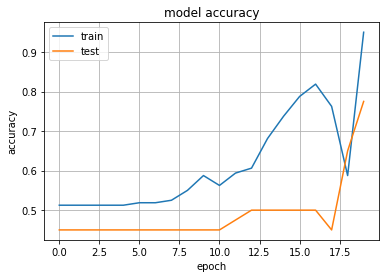

In [ ]:
from  matplotlib import pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix,f1_score, precision_score,recall_score


In [ ]:
y_predict  = [1 if o>0.5 else 0 for o in model.predict(x_test_features)]


In [ ]:
cf_matrix =confusion_matrix(test_y,y_predict)


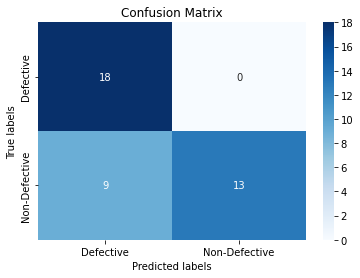

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ax= plt.subplot()
sns.heatmap(cf_matrix, annot=True, ax = ax,cmap='Blues',fmt=''); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['Defective', 'Non-Defective']); ax.yaxis.set_ticklabels(['Defective', 'Non-Defective']);

In [ ]:
tn, fp, fn, tp = confusion_matrix(test_y,y_predict).ravel()


In [ ]:
print("Precision: {:.2f}%".format(100 * precision_score(test_y, y_predict)))
print("Recall: {:.2f}%".format(100 * recall_score(test_y, y_predict)))
print("F1 Score: {:.2f}%".format(100 * f1_score(test_y,y_predict)))

Precision: 100.00%
Recall: 59.09%
F1 Score: 74.29%


In [ ]:
f1_score(test_y,y_predict)


0.7428571428571429